# Shipping Traffic Analysis - Strait of Hormuz

This notebook analyzes shipping traffic patterns through the Strait of Hormuz during normal periods vs. conflict periods.

## Key Questions:
1. How many ships pass through during normal operations?
2. How does traffic change during geopolitical crises?
3. What types of vessels are most affected?
4. How long do disruptions typically last?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_acquisition import DataAcquisition
from shipping_monitor import ShippingMonitor
import yaml

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Load config
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

## 1. Load Shipping Data

In [3]:
# Fetch data
acq = DataAcquisition()
data = acq.fetch_all_data()
shipping_df = data['shipping']
print(f"Loaded {len(shipping_df)} days of shipping data")
print(f"Date range: {shipping_df.index[0]} to {shipping_df.index[-1]}")
shipping_df.head()

✓ Databento client initialized
✓ Alpaca clients initialized
✓ yfinance available (no key required)

STRAIT OF HORMUZ STRATEGY - DATA ACQUISITION

Fetching market data...
  → Fetching equities...
    ✓ Fetched via Alpaca
  → Fetching fixed income...
    ⚠ Error: 'Adj Close'
  → Fetching futures...
    ✓ Loading from cache
  → Fetching commodities...
    ⚠ Error: 'Adj Close'
  → Fetching currencies...
    ⚠ Error: 'Adj Close'
  → Fetching crypto...
    ✓ Fetched 2 cryptos via Binance
Fetching shipping traffic data...
Loading PortWatch IMF shipping data...
✓ Loaded 2617 days of shipping data
  Date range: 2019-01-01 to 2026-03-01
  Vessel types: Container, Dry Bulk, General Cargo, Roll-on/roll-off, Tanker
✓ Loaded REAL PortWatch IMF data: 2256 days
Fetching geopolitical events...
  → Fetching news sentiment with LLM analysis...
✓ GDELT client initialized
✓ NewsAPI client initialized
✓ Alpaca News client initialized
✓ Google Search API configured
✓ LLM Sentiment Analyzer initialized (opena

,tanker_transits,container_transits,dry_bulk_transits,general_cargo_transits,roro_transits,total_transits,lng_transits,ma_7day,ma_7day_prior_year
date,,,,,,,,,
2019-01-01,51,11,11,3,3,79,20.4,NaN,NaN
2019-01-02,55,13,11,0,4,83,22.0,NaN,NaN
2019-01-03,58,15,15,5,1,94,23.2,NaN,NaN
2019-01-04,41,10,14,2,2,69,16.4,NaN,NaN
2019-01-05,51,12,14,3,1,81,20.4,NaN,NaN


## 2. Normal vs. Crisis Traffic Patterns

In [4]:
# Analyze with shipping monitor
monitor = ShippingMonitor()
analyzed = monitor.detect_anomalies(shipping_df)

# Summary statistics by alert level
summary = analyzed.groupby('alert_level')['tanker_transits'].agg([
    'count', 'mean', 'std', 'min', 'max'
])
summary.columns = ['Days', 'Avg Transits', 'Std Dev', 'Min', 'Max']
print("\nShipping Traffic by Alert Level:")
print(summary)


Shipping Traffic by Alert Level:
             Days  Avg Transits   Std Dev  Min  Max
alert_level                                        
alert          29     36.655172  4.775502   26   44
normal       2227     56.642568  9.464633   34   90


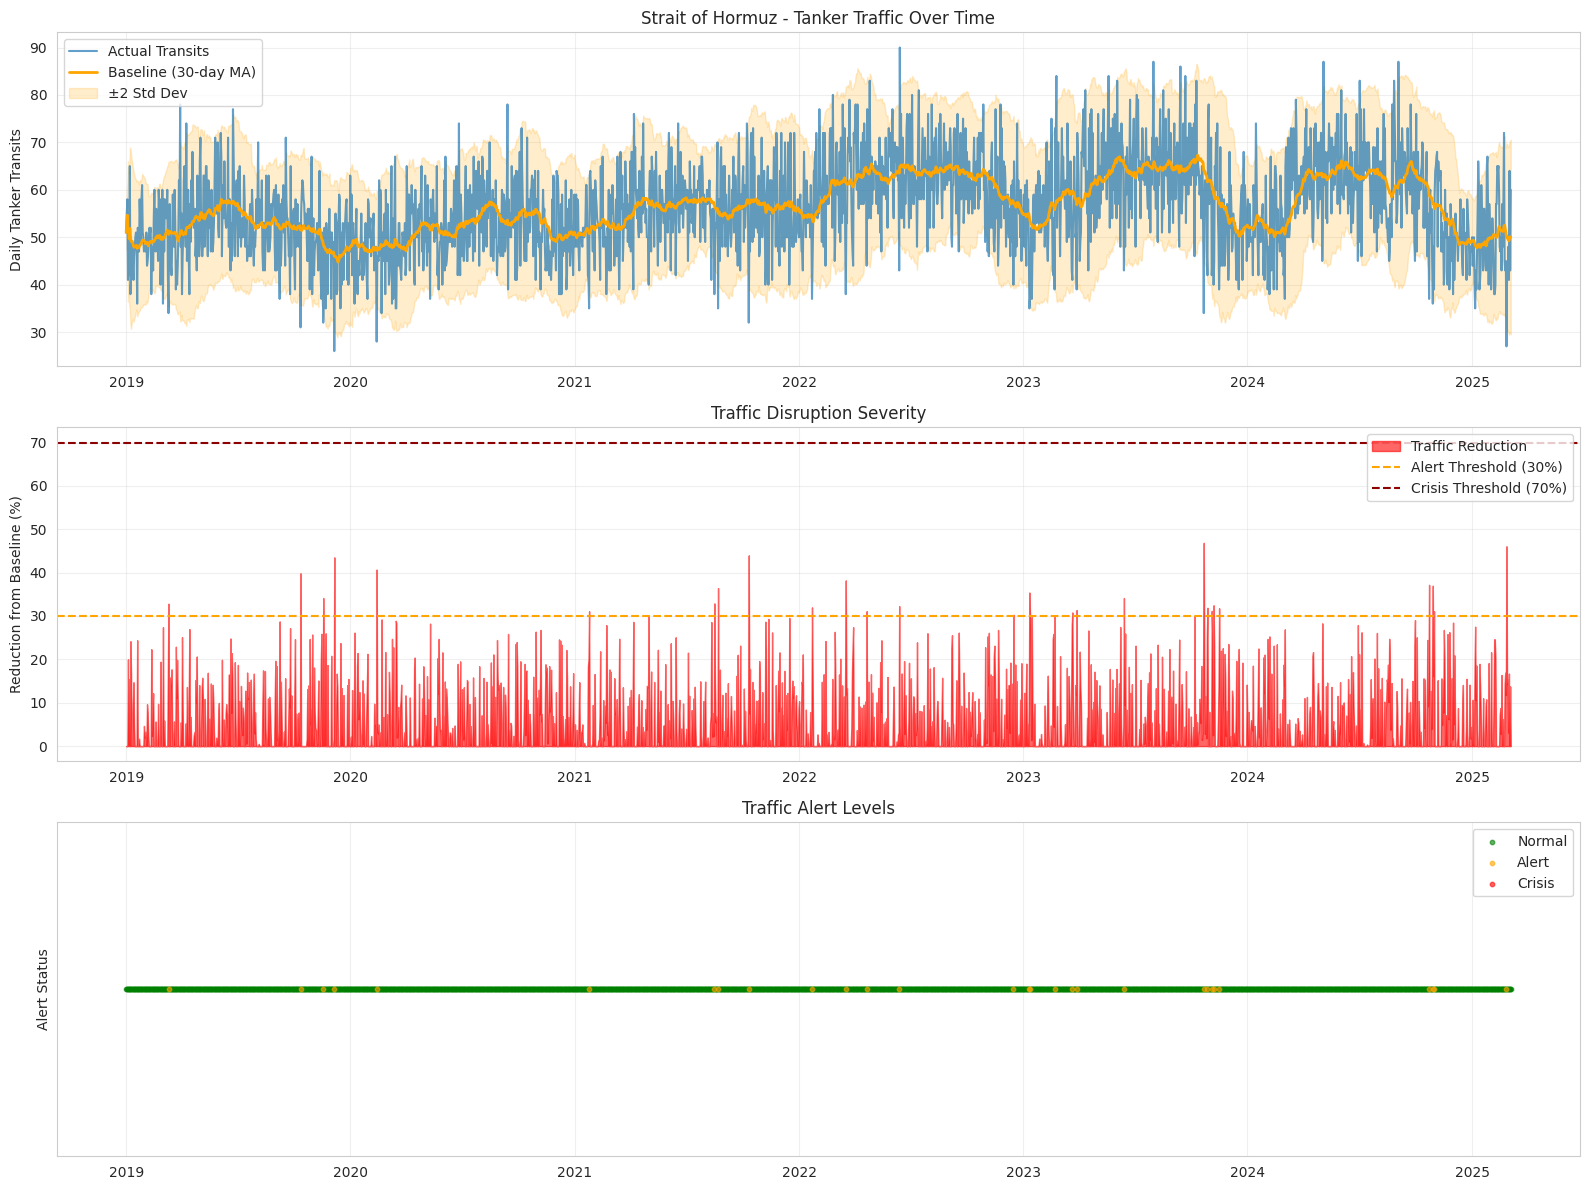

In [5]:
# Visualize traffic over time
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Raw traffic with baseline
axes[0].plot(analyzed.index, analyzed['tanker_transits'], label='Actual Transits', alpha=0.7)
axes[0].plot(analyzed.index, analyzed['baseline_mean'], label='Baseline (30-day MA)', 
             color='orange', linewidth=2)
axes[0].fill_between(analyzed.index, 
                      analyzed['baseline_mean'] - 2*analyzed['baseline_std'],
                      analyzed['baseline_mean'] + 2*analyzed['baseline_std'],
                      alpha=0.2, color='orange', label='±2 Std Dev')
axes[0].set_ylabel('Daily Tanker Transits')
axes[0].set_title('Strait of Hormuz - Tanker Traffic Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Reduction percentage
axes[1].fill_between(analyzed.index, 0, analyzed['reduction_pct']*100, 
                      alpha=0.6, color='red', label='Traffic Reduction')
axes[1].axhline(y=30, color='orange', linestyle='--', label='Alert Threshold (30%)')
axes[1].axhline(y=70, color='darkred', linestyle='--', label='Crisis Threshold (70%)')
axes[1].set_ylabel('Reduction from Baseline (%)')
axes[1].set_title('Traffic Disruption Severity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Alert levels
alert_colors = {'normal': 'green', 'alert': 'orange', 'crisis': 'red'}
for level, color in alert_colors.items():
    mask = analyzed['alert_level'] == level
    axes[2].scatter(analyzed.index[mask], [1]*mask.sum(), 
                   c=color, label=level.capitalize(), alpha=0.6, s=10)
axes[2].set_ylabel('Alert Status')
axes[2].set_title('Traffic Alert Levels')
axes[2].set_yticks([])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Crisis Period Analysis

In [6]:
# Identify crisis periods
crisis_periods = monitor.analyze_crisis_periods(shipping_df)

if len(crisis_periods) > 0:
    print(f"\nIdentified {len(crisis_periods)} crisis periods:\n")
    print(crisis_periods.to_string(index=False))
    
    # Visualize crisis periods
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(analyzed.index, analyzed['tanker_transits'], label='Tanker Transits', alpha=0.7)
    
    # Highlight crisis periods
    for _, period in crisis_periods.iterrows():
        ax.axvspan(period['start_date'], period['end_date'], 
                  alpha=0.3, color='red', label='Crisis Period' if _ == 0 else '')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Tanker Transits')
    ax.set_title('Crisis Periods - Shipping Traffic Disruptions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print("No crisis periods detected in the data.")

No crisis periods detected in the data.


## 4. Vessel Type Analysis

In [ ]:
# Compare vessel types
vessel_data = shipping_df[['tanker_transits', 'lng_transits', 'total_transits']].copy()

# Calculate statistics
vessel_stats = vessel_data.describe().T
print("\nVessel Type Statistics:")
print(vessel_stats)

# Visualize vessel type distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Time series
vessel_data.plot(ax=axes[0], alpha=0.7)
axes[0].set_ylabel('Daily Transits')
axes[0].set_title('Vessel Traffic by Type')
axes[0].legend(['Crude Oil Tankers', 'LNG Carriers', 'Total'])
axes[0].grid(True, alpha=0.3)

# Distribution
vessel_data.plot(kind='box', ax=axes[1])
axes[1].set_ylabel('Daily Transits')
axes[1].set_title('Traffic Distribution by Vessel Type')
axes[1].set_xticklabels(['Crude Oil\nTankers', 'LNG\nCarriers', 'Total'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Seasonal Patterns

In [ ]:
# Extract seasonal components
shipping_df['month'] = shipping_df.index.month
shipping_df['day_of_week'] = shipping_df.index.dayofweek

# Monthly patterns
monthly_avg = shipping_df.groupby('month')['tanker_transits'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly seasonality
monthly_avg.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Daily Transits')
axes[0].set_title('Seasonal Pattern - Monthly Average Traffic')
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[0].grid(True, alpha=0.3)

# Day of week patterns
dow_avg = shipping_df.groupby('day_of_week')['tanker_transits'].mean()
dow_avg.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Daily Transits')
axes[1].set_title('Weekly Pattern - Day of Week Traffic')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Key Findings Summary

In [ ]:
# Calculate key metrics
normal_traffic = analyzed[analyzed['alert_level'] == 'normal']['tanker_transits'].mean()
crisis_traffic = analyzed[analyzed['alert_level'] == 'crisis']['tanker_transits'].mean()
avg_reduction = (1 - crisis_traffic / normal_traffic) * 100

crisis_days = (analyzed['alert_level'] == 'crisis').sum()
total_days = len(analyzed)
crisis_pct = crisis_days / total_days * 100

print("="*60)
print("KEY FINDINGS - SHIPPING TRAFFIC ANALYSIS")
print("="*60)
print(f"\n1. NORMAL OPERATIONS:")
print(f"   Average daily tanker transits: {normal_traffic:.1f}")
print(f"   Normal operation days: {(analyzed['alert_level'] == 'normal').sum()} ({(analyzed['alert_level'] == 'normal').sum()/total_days*100:.1f}%)")

print(f"\n2. CRISIS PERIODS:")
print(f"   Average daily tanker transits: {crisis_traffic:.1f}")
print(f"   Average traffic reduction: {avg_reduction:.1f}%")
print(f"   Crisis days: {crisis_days} ({crisis_pct:.1f}%)")
print(f"   Number of crisis events: {len(crisis_periods) if len(crisis_periods) > 0 else 0}")

if len(crisis_periods) > 0:
    print(f"   Average crisis duration: {crisis_periods['duration_days'].mean():.1f} days")
    print(f"   Maximum crisis duration: {crisis_periods['duration_days'].max():.0f} days")

print(f"\n3. ECONOMIC IMPACT:")
print(f"   Daily oil flow (normal): ~{normal_traffic * 2:.0f} million barrels")
print(f"   Daily oil flow (crisis): ~{crisis_traffic * 2:.0f} million barrels")
print(f"   Daily disruption: ~{(normal_traffic - crisis_traffic) * 2:.0f} million barrels")
print(f"   % of global oil supply affected: ~{(normal_traffic - crisis_traffic) * 2 / 100 * 100:.1f}%")

print("\n" + "="*60)